# PINN Simulation: 2D Heat Transfer in Food Processing

This notebook implements a **Physics-Informed Neural Network (PINN)** to solve the transient 2D heat diffusion equation for a food product during oven heating — without any mesh or finite-element discretization.

**Governing equation:**

$$\frac{\partial T}{\partial t} = \alpha \left( \frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} \right)$$

where $\alpha = k / (\rho\, c_p)$ is the thermal diffusivity.

| Parameter | Symbol | Value | Unit |
| :--- | :---: | :---: | :--- |
| Thermal Conductivity | $k$ | 0.45 | W/(m K) |
| Density | $\rho$ | 1 050 | kg/m³ |
| Specific Heat | $c_p$ | 3 300 | J/(kg K) |
| Thermal Diffusivity | $\alpha$ | 1.30 × 10⁻⁷ | m²/s |

**Domain:** 10 cm × 10 cm cross-section &nbsp;|&nbsp; **IC:** 25 °C uniform &nbsp;|&nbsp; **BC:** 180 °C on all edges &nbsp;|&nbsp; **Duration:** 60 min

---
*Source code for the book chapter "Digital Twins and Physics-Informed Neural Networks in Food Processing" (AI for Food Science).*

## 1 — Setup & Imports

In [1]:
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global plot style
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 2 — Physical Parameters & Domain

In [2]:
# Material properties (moist food product)
k   = 0.45       # thermal conductivity  [W/(m·K)]
rho = 1050.0     # density               [kg/m³]
cp  = 3300.0     # specific heat         [J/(kg·K)]

alpha = k / (rho * cp)   # thermal diffusivity [m²/s]

# Geometry (10 cm × 10 cm, stored in metres)
Lx = 0.10   # [m]
Ly = 0.10   # [m]

# Temperatures
T_OVEN   = 180.0   # boundary temperature  [°C]
T_INIT   =  25.0   # initial temperature   [°C]

# Time
t_final_min = 60.0
t_final_sec = t_final_min * 60.0   # 3 600 s

print(f"α = {alpha:.4e} m²/s")
print(f"Domain: {Lx*100:.0f} cm × {Ly*100:.0f} cm")
print(f"Duration: {t_final_min:.0f} min ({t_final_sec:.0f} s)")

α = 1.2987e-07 m²/s
Domain: 10 cm × 10 cm
Duration: 60 min (3600 s)


## 3 — Network Architecture

The PINN takes normalised inputs $(\hat x, \hat y, \hat t) \in [0,1]^3$ and outputs a single value $u \in [0,1]$ via a sigmoid, where

$$T = T_{\text{init}} + u\,(T_{\text{oven}} - T_{\text{init}})$$

Hidden layers use `tanh` activations — smoother than ReLU and better suited for learning continuous temperature fields.

In [3]:
class PINN(nn.Module):
    """Fully-connected network for physics-informed temperature prediction."""

    def __init__(self, layer_sizes):
        super().__init__()
        layers = []
        for i in range(len(layer_sizes) - 1):
            lin = nn.Linear(layer_sizes[i], layer_sizes[i + 1])
            nn.init.xavier_uniform_(lin.weight)
            nn.init.zeros_(lin.bias)
            layers.append(lin)
        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = torch.tanh(layer(x))
        return torch.sigmoid(self.layers[-1](x))   # u ∈ [0, 1]

## 4 — Collocation-Point Samplers

At each training step we randomly sample three sets of points:

| Set | Purpose | Target |
|-----|---------|--------|
| Interior | Enforce the PDE residual ≈ 0 | — |
| IC | $T(x,y,0) = 25$ °C → $u=0$ | 0 |
| BC | $T(\text{edge},t) = 180$ °C → $u=1$ | 1 |

In [4]:
def sample_interior(N):
    """Random interior points in [0,1]³ with gradients enabled."""
    x = torch.rand(N, 1, device=device, requires_grad=True)
    y = torch.rand(N, 1, device=device, requires_grad=True)
    t = torch.rand(N, 1, device=device, requires_grad=True)
    return x, y, t


def sample_initial(N):
    """IC points at t = 0, target u = 0."""
    x = torch.rand(N, 1, device=device)
    y = torch.rand(N, 1, device=device)
    t = torch.zeros(N, 1, device=device)
    u_target = torch.zeros(N, 1, device=device)
    return x, y, t, u_target


def sample_boundary(N):
    """BC points on all four edges, target u = 1."""
    n = N // 4

    # Left (x=0), Right (x=1), Bottom (y=0), Top (y=1)
    xs = [torch.zeros(n, 1, device=device),
          torch.ones(n, 1, device=device),
          torch.rand(n, 1, device=device),
          torch.rand(n, 1, device=device)]

    ys = [torch.rand(n, 1, device=device),
          torch.rand(n, 1, device=device),
          torch.zeros(n, 1, device=device),
          torch.ones(n, 1, device=device)]

    ts = [torch.rand(n, 1, device=device) for _ in range(4)]

    x = torch.cat(xs)
    y = torch.cat(ys)
    t = torch.cat(ts)
    u_target = torch.ones(x.shape[0], 1, device=device)
    return x, y, t, u_target

## 5 — PDE Residual

After non-dimensionalising with $\hat x = x/L$, $\hat t = t / t_f$, the heat equation becomes:

$$\frac{\partial u}{\partial \hat t} = \underbrace{\frac{\alpha\, t_f}{L^2}}_{\text{coeff}} \left( \frac{\partial^2 u}{\partial \hat x^2} + \frac{\partial^2 u}{\partial \hat y^2} \right)$$

We compute the residual $R$ using PyTorch's automatic differentiation.

In [5]:
# Pre-compute the non-dimensional PDE coefficient
PDE_COEFF = (alpha * t_final_sec) / (Lx ** 2)
print(f"PDE coefficient (α·t_f / L²) = {PDE_COEFF:.4f}")


def pde_residual(model, x, y, t):
    """Return the PDE residual R = du/dt - coeff·(d²u/dx² + d²u/dy²)."""
    u = model(torch.cat([x, y, t], dim=1))

    # First derivatives
    ones = torch.ones_like(u)
    du_dx = torch.autograd.grad(u, x, ones, create_graph=True)[0]
    du_dy = torch.autograd.grad(u, y, ones, create_graph=True)[0]
    du_dt = torch.autograd.grad(u, t, ones, create_graph=True)[0]

    # Second derivatives
    d2u_dx2 = torch.autograd.grad(du_dx, x, ones, create_graph=True)[0]
    d2u_dy2 = torch.autograd.grad(du_dy, y, ones, create_graph=True)[0]

    return du_dt - PDE_COEFF * (d2u_dx2 + d2u_dy2)

PDE coefficient (α·t_f / L²) = 0.0468


## 6 — Training

We minimise a composite loss:

$$\mathcal{L} = w_{\text{pde}}\,\mathcal{L}_{\text{pde}} + w_{\text{ic}}\,\mathcal{L}_{\text{ic}} + w_{\text{bc}}\,\mathcal{L}_{\text{bc}}$$

All three weights are set to **1.0** (equal weighting). The Adam optimiser is used with an initial learning rate of 10⁻³.

In [6]:
# --- Hyper-parameters ---
LAYER_SIZES = [3, 64, 64, 64, 64, 1]   # 3 inputs → 4 hidden → 1 output
NUM_EPOCHS  = 6000
LR          = 1e-3

N_INT = 2000   # interior (PDE) points per epoch
N_IC  =  500   # initial-condition points
N_BC  =  800   # boundary-condition points (divisible by 4)

W_PDE = 1.0
W_IC  = 1.0
W_BC  = 1.0

# --- Initialise model & optimiser ---
model     = PINN(LAYER_SIZES).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)
mse       = nn.MSELoss()

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Training for {NUM_EPOCHS:,} epochs …")

Model parameters: 12,801
Training for 6,000 epochs …


In [7]:
# --- Training loop ---
history = {"total": [], "pde": [], "ic": [], "bc": []}

for epoch in range(NUM_EPOCHS):
    optimizer.zero_grad()

    # PDE residual on interior points
    x_i, y_i, t_i = sample_interior(N_INT)
    loss_pde = mse(pde_residual(model, x_i, y_i, t_i),
                   torch.zeros(N_INT, 1, device=device))

    # Initial condition
    x_ic, y_ic, t_ic, u_ic = sample_initial(N_IC)
    loss_ic = mse(model(torch.cat([x_ic, y_ic, t_ic], dim=1)), u_ic)

    # Boundary condition
    x_bc, y_bc, t_bc, u_bc = sample_boundary(N_BC)
    loss_bc = mse(model(torch.cat([x_bc, y_bc, t_bc], dim=1)), u_bc)

    # Weighted total
    loss = W_PDE * loss_pde + W_IC * loss_ic + W_BC * loss_bc
    loss.backward()
    optimizer.step()

    # Record
    history["total"].append(loss.item())
    history["pde"].append(loss_pde.item())
    history["ic"].append(loss_ic.item())
    history["bc"].append(loss_bc.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d}  |  Total {loss.item():.3e}  "
              f"(PDE {loss_pde.item():.2e}  IC {loss_ic.item():.2e}  BC {loss_bc.item():.2e})")

print("\nTraining complete.")

Epoch     0  |  Total 4.737e-01  (PDE 5.75e-03  IC 2.78e-01  BC 1.90e-01)


Epoch   500  |  Total 1.268e-01  (PDE 1.70e-02  IC 2.93e-02  BC 8.05e-02)


Epoch  1000  |  Total 9.286e-02  (PDE 1.07e-02  IC 1.46e-02  BC 6.76e-02)


Epoch  1500  |  Total 7.680e-02  (PDE 1.30e-02  IC 1.19e-02  BC 5.20e-02)


Epoch  2000  |  Total 5.837e-02  (PDE 7.37e-03  IC 9.74e-03  BC 4.13e-02)


...

Epoch  4000  |  Total 4.008e-02  (PDE 8.44e-03  IC 8.29e-03  BC 2.34e-02)


Epoch  4500  |  Total 3.243e-02  (PDE 5.64e-03  IC 4.88e-03  BC 2.19e-02)


Epoch  5000  |  Total 3.648e-02  (PDE 1.43e-02  IC 5.20e-03  BC 1.70e-02)


Epoch  5500  |  Total 3.741e-02  (PDE 6.09e-03  IC 4.34e-03  BC 2.70e-02)



Training complete.


## 7 — Results

### 7.1 Loss Convergence

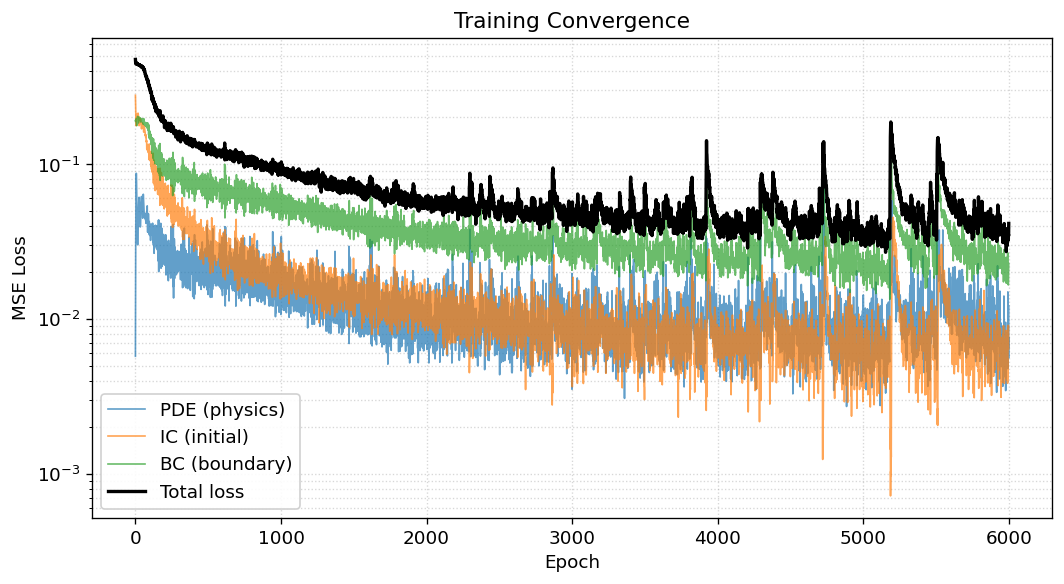

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

epochs = np.arange(len(history["total"]))
ax.plot(epochs, history["pde"],   label="PDE (physics)",  alpha=0.7, lw=1)
ax.plot(epochs, history["ic"],    label="IC (initial)",   alpha=0.7, lw=1)
ax.plot(epochs, history["bc"],    label="BC (boundary)",  alpha=0.7, lw=1)
ax.plot(epochs, history["total"], label="Total loss",     color="black", lw=2)

ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Training Convergence")
ax.legend(framealpha=0.9)
ax.grid(True, which="both", ls=":", alpha=0.5)

fig.tight_layout()
plt.show()

### 7.2 Temperature Snapshots

In [ ]:
def plot_snapshots(times_min, save_path=None):
    """Plot temperature contour maps at the given time snapshots."""
    n_plots = len(times_min)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4.5))
    if n_plots == 1:
        axes = [axes]

    # Spatial grid (physical units for axis labels)
    x_cm = np.linspace(0, Lx * 100, 100)
    y_cm = np.linspace(0, Ly * 100, 100)
    X, Y = np.meshgrid(x_cm, y_cm)

    # Normalised coordinates for the model
    x_hat = torch.tensor(X.flatten() / (Lx * 100), dtype=torch.float32).unsqueeze(1).to(device)
    y_hat = torch.tensor(Y.flatten() / (Ly * 100), dtype=torch.float32).unsqueeze(1).to(device)

    levels = np.linspace(T_INIT, T_OVEN, 100)
    ticks  = np.arange(20, 200, 20)

    for i, t_min in enumerate(times_min):
        t_hat = torch.full_like(x_hat, (t_min * 60.0) / t_final_sec)

        with torch.no_grad():
            u = model(torch.cat([x_hat, y_hat, t_hat], dim=1))
            T = T_INIT + u * (T_OVEN - T_INIT)

        T_grid = T.cpu().numpy().reshape(100, 100)
        cf = axes[i].contourf(X, Y, T_grid, levels=levels, cmap="inferno", extend="both")
        axes[i].set_aspect("equal")
        axes[i].set_title(f"t = {t_min} min")
        axes[i].set_xlabel("x (cm)")
        if i == 0:
            axes[i].set_ylabel("y (cm)")
        else:
            axes[i].set_yticks([])

    cbar = fig.colorbar(cf, ax=axes, shrink=0.85, pad=0.03, ticks=ticks)
    cbar.set_label("Temperature (°C)")

    fig.suptitle("2D Temperature Distribution — Cross Section", fontsize=14, y=1.02)
    fig.subplots_adjust(wspace=0.05)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved → {save_path}")

    plt.show()


plot_snapshots([0, 10, 30, 60], save_path="Simulation_Result.png")

### 7.3 Centre-Point Thermal History

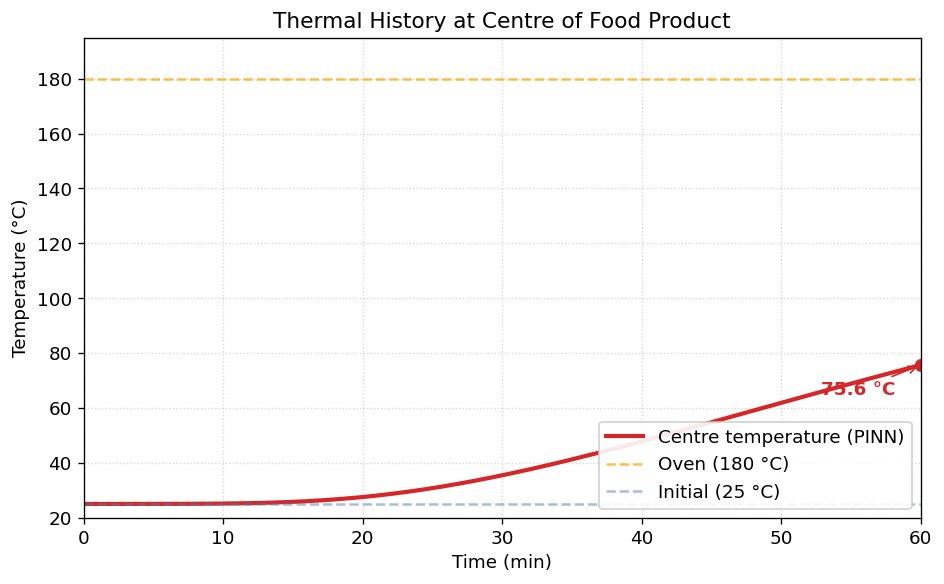

In [10]:
def plot_centre_history():
    """Temperature vs time at the geometric centre (coldest point)."""
    t_min = np.linspace(0, t_final_min, 200)
    t_hat = torch.tensor(t_min * 60 / t_final_sec, dtype=torch.float32).view(-1, 1).to(device)
    x_hat = torch.full_like(t_hat, 0.5)
    y_hat = torch.full_like(t_hat, 0.5)

    with torch.no_grad():
        u = model(torch.cat([x_hat, y_hat, t_hat], dim=1))
        T = (T_INIT + u * (T_OVEN - T_INIT)).cpu().numpy()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(t_min, T, color="#d62728", lw=2.5, label="Centre temperature (PINN)")
    ax.axhline(T_OVEN, color="orange", ls="--", alpha=0.7, label=f"Oven ({T_OVEN:.0f} °C)")
    ax.axhline(T_INIT, color="steelblue", ls="--", alpha=0.5, label=f"Initial ({T_INIT:.0f} °C)")

    final = T[-1, 0]
    ax.plot(t_final_min, final, "o", color="#d62728", ms=7)
    ax.annotate(f"{final:.1f} °C", xy=(t_final_min, final),
                xytext=(-60, -18), textcoords="offset points",
                fontweight="bold", color="#d62728",
                arrowprops=dict(arrowstyle="->", color="#d62728"))

    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Temperature (°C)")
    ax.set_title("Thermal History at Centre of Food Product")
    ax.set_xlim(0, t_final_min)
    ax.set_ylim(20, 195)
    ax.legend(loc="lower right", framealpha=0.9)
    ax.grid(True, ls=":", alpha=0.5)

    fig.tight_layout()
    plt.show()


plot_centre_history()